# 03 - Behavioural Cloning (from scratch)

We clone the expert with a **from-scratch PyTorch MLP** trained by supervised learning. Because the action space is the discrete 90-way `LookupAction`, this is **multi-class classification** with **cross-entropy** loss - not regression.

`BCStudent` is an MLP `107 -> hidden -> 90 logits`. Its layer layout mirrors `rlgym-ppo`'s `DiscreteFF` exactly (Linear+ReLU stack, logits head), so a trained student exports to a `PPO_POLICY.pt` that the repo's existing `evaluate.py` / `tournament.py` / `make_match_video.py` load with no changes - which is how we measure win-rate and render video later.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make imitation/ importable -> il_core (cwd = notebooks/)
import il_core
il_core.use_repo_cwd()                       # chdir to repo root so RocketSim finds ./collision_meshes/
import numpy as np
import matplotlib.pyplot as plt
from il_core import (ExpertPolicy, BCStudent, DemoBuffer, collect_expert_demos,
                     train_bc, rollout_student_relabel, evaluate_student_winrate,
                     save_student_checkpoint, build_env, OBS_DIM, N_ACTIONS,
                     EXPERT_CKPT, DATA_DIR, ARTIFACT_DIR, REPO_ROOT)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('engine loaded | OBS_DIM', OBS_DIM, '| N_ACTIONS', N_ACTIONS)

engine loaded | OBS_DIM 107 | N_ACTIONS 90


### Honest train/val split: hold out whole EPISODES
Frames are collected sequentially and at ~15 Hz consecutive frames are near-identical with the same label. A *random* frame split would scatter near-duplicate neighbours across train and val and **inflate** accuracy (it measures interpolation between adjacent frames, not generalization). So we hold out **whole episodes** (`split_by_episode`) and use that one fixed val set everywhere below.

In [2]:
from il_core import split_by_episode
buf = DemoBuffer.load(DATA_DIR)
tr_idx, val_idx = split_by_episode(buf, val_frac=0.2, seed=0)
Xtr, ytr = buf.observations[tr_idx], buf.actions[tr_idx]
Xval, yval = buf.observations[val_idx], buf.actions[val_idx]
n_val_eps = len(set(buf.episode_ids[val_idx].tolist()))
print(f'train {len(ytr)} frames | val {len(yval)} frames from {n_val_eps} held-out episodes')
device = il_core.pick_device(); print('train device:', device)

train 11480 frames | val 2656 frames from 6 held-out episodes
train device: cuda


## Train the baseline BC student
Cross-entropy on the training episodes; accuracy on the held-out episodes.

In [3]:
student = BCStudent(hidden_sizes=(256, 256))
res = train_bc(student, Xtr, ytr, val_data=(Xval, yval), epochs=80, batch_size=512, lr=1e-3, verbose=True)
print('\nfinal (episode-held-out)  top-1:', round(res['val_acc'], 3), '| top-3:', round(res['val_top3'], 3))
save_student_checkpoint(student, os.path.join(ARTIFACT_DIR, 'bc_student'))

  epoch   1/80  train 3.812  val 3.418  acc 0.200  top3 0.377


  epoch   9/80  train 2.477  val 2.723  acc 0.323  top3 0.518


  epoch  17/80  train 2.062  val 2.658  acc 0.324  top3 0.541


  epoch  25/80  train 1.771  val 2.759  acc 0.314  top3 0.521


  epoch  33/80  train 1.554  val 2.860  acc 0.323  top3 0.517


...

  epoch  65/80  train 1.008  val 3.558  acc 0.303  top3 0.497


  epoch  73/80  train 0.904  val 3.670  acc 0.317  top3 0.496


  epoch  80/80  train 0.841  val 3.810  acc 0.309  top3 0.505



final (episode-held-out)  top-1: 0.309 | top-3: 0.505


'C:\\Users\\Lasca\\Desktop\\Pro\\IE\\Courses\\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\\Group Project\\rlgym\\imitation\\artifacts\\bc_student'

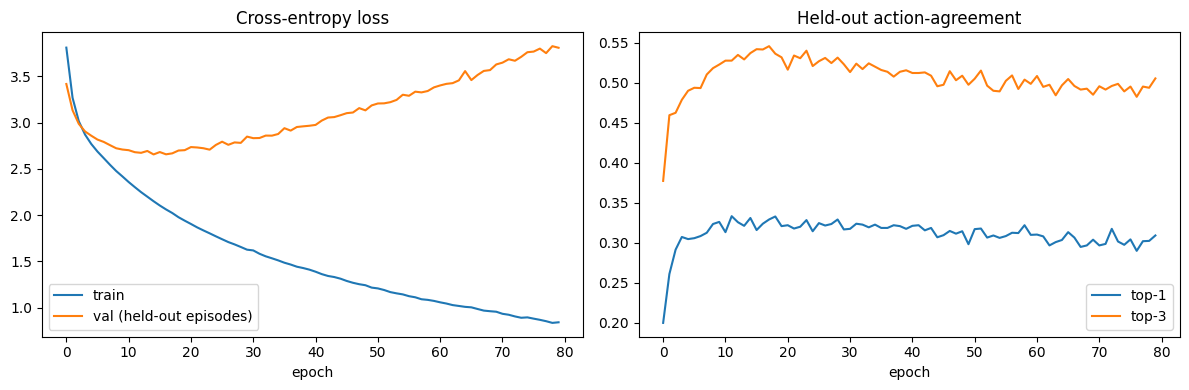

In [4]:
h = res['history']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['train_loss'], label='train'); ax[0].plot(h['val_loss'], label='val (held-out episodes)')
ax[0].set_title('Cross-entropy loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(h['val_acc'], label='top-1'); ax[1].plot(h['val_top3'], label='top-3')
ax[1].set_title('Held-out action-agreement'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

## Ablation 1 - dataset size
**Research question:** how does BC accuracy scale with the number of demonstrations? We retrain on increasing fractions of the **training** frames and evaluate every model on the **same fixed held-out episodes** - so the only thing changing is training-set size. More expert data should help (up to a point) - the empirical face of BC's sample complexity.

    1148 train frames -> held-out acc 0.246


    2870 train frames -> held-out acc 0.265


    5740 train frames -> held-out acc 0.271


    8610 train frames -> held-out acc 0.299


   11480 train frames -> held-out acc 0.288


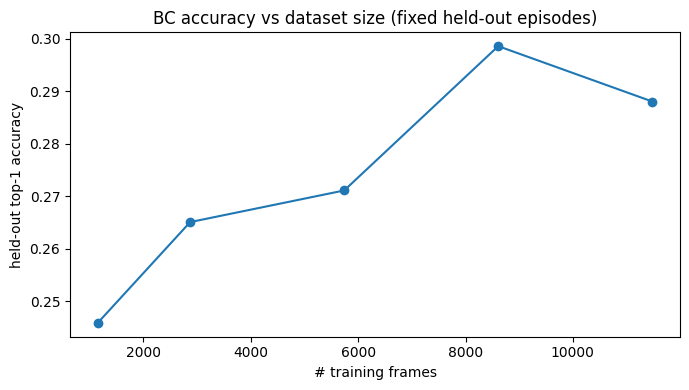

In [5]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
sizes, accs = [], []
rng = np.random.default_rng(0)
for f in fractions:
    m = max(64, int(len(ytr) * f))
    sub = rng.permutation(len(ytr))[:m]
    s = BCStudent(hidden_sizes=(256, 256))
    r = train_bc(s, Xtr[sub], ytr[sub], val_data=(Xval, yval), epochs=60, batch_size=512, lr=1e-3)
    sizes.append(m); accs.append(r['val_acc'])
    print(f'  {m:6d} train frames -> held-out acc {r["val_acc"]:.3f}')
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, accs, 'o-'); ax.set_xlabel('# training frames'); ax.set_ylabel('held-out top-1 accuracy')
ax.set_title('BC accuracy vs dataset size (fixed held-out episodes)'); plt.tight_layout(); plt.show()

## Ablation 2 - network capacity
**Research question:** does a wider student clone the expert better? We hold **depth fixed at 3 layers** and vary only the **width**, evaluating on the same fixed held-out episodes. (Single seed, so read small differences as within-noise rather than a strong capacity law.)

  narrow (128x3) -> held-out acc 0.312


  mid (256x3)    -> held-out acc 0.289


  wide (512x3)   -> held-out acc 0.305


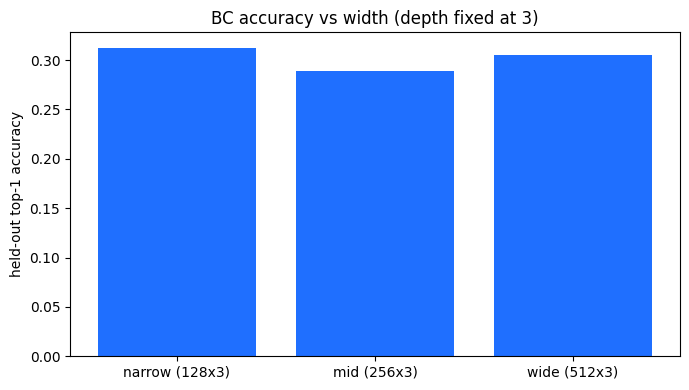

In [6]:
archs = {'narrow (128x3)': (128, 128, 128), 'mid (256x3)': (256, 256, 256), 'wide (512x3)': (512, 512, 512)}
names, cap_acc = [], []
for name, hs in archs.items():
    s = BCStudent(hidden_sizes=hs)
    r = train_bc(s, Xtr, ytr, val_data=(Xval, yval), epochs=60, batch_size=512, lr=1e-3)
    names.append(name); cap_acc.append(r['val_acc'])
    print(f'  {name:14s} -> held-out acc {r["val_acc"]:.3f}')
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, cap_acc, color='#1f6fff'); ax.set_ylabel('held-out top-1 accuracy')
ax.set_title('BC accuracy vs width (depth fixed at 3)'); plt.tight_layout(); plt.show()

## Discussion
- **Classification, not regression.** Cross-entropy over 90 discrete actions is the correct objective; MSE on action indices would be meaningless (action 89 is not '89x' action 1).
- **Leak-free evaluation.** We split by whole episodes; a naive random frame split inflates accuracy on this 15 Hz sequential data because adjacent near-duplicate frames leak across train and val.
- **The covariate-shift problem.** BC only ever sees *expert* states. At deployment the student makes small errors, drifts into states the expert never visited, and has no idea what to do there - errors compound as **O(eps*T^2)** over a horizon T. Even a respectable held-out accuracy does **not** guarantee good play (notebook 04 shows the clone winning ~0% despite this). That gap is exactly what **DAgger** fixes.
- **Scaling.** Accuracy rises with more demonstrations; widening the net helps only marginally here (single seed - treat small gaps as noise). Both matter less than fixing the distribution mismatch.